<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Salary.csv")
df.sample(5)

,YearsExperience,Salary
34,13.5,139465
4,2.2,39891
10,3.9,63218
11,4.0,55794
18,5.9,81363


In [ ]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [ ]:
X.sample(5)

,YearsExperience
30,11.2
24,8.7
3,2.0
31,11.5
27,9.6


In [ ]:
y.sample(5)

,Salary
8,64445
19,93940
24,109431
7,54445
29,121872


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
X.shape

(35, 1)

In [ ]:
X_train.shape

(28, 1)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_predict = lr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)

0.9452036450419026

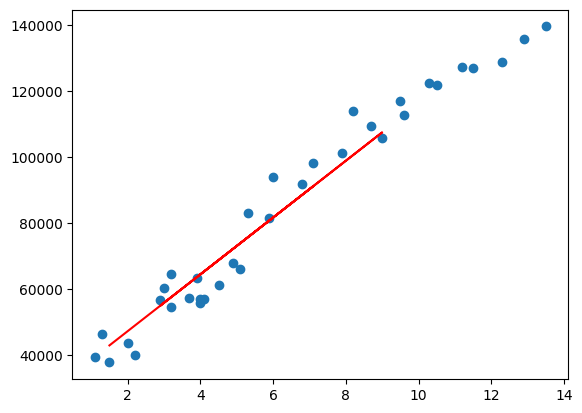

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.plot(X_test,y_predict,c='r')

How Linear Regression algorithm works


In [ ]:
X1 = df.iloc[:,0:1]
y1 = df.iloc[:,1]

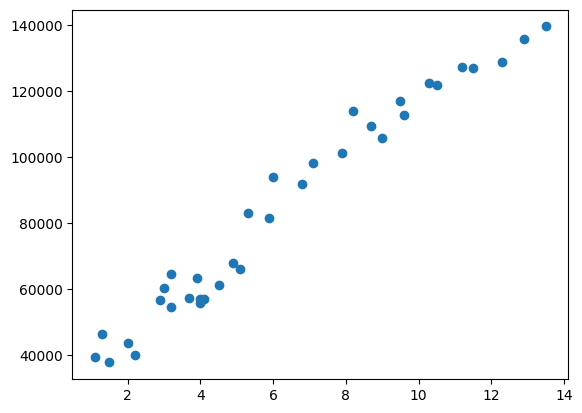

In [ ]:
plt.scatter(X1,y1)

In [ ]:
lr1 = LinearRegression()
lr1.fit(X1,y1)

LinearRegression()

In [ ]:
lr1.coef_

array([8731.94104706])

In [ ]:
lr1.intercept_

28859.52619453144

In [ ]:
#1 assume m = 8000 and b = 28000

y_pred = (7000*X1+25000)

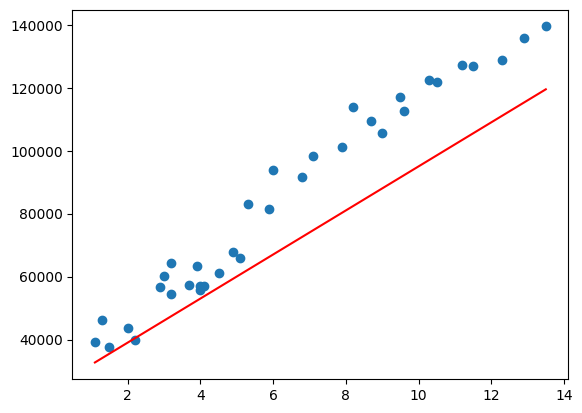

In [ ]:
plt.scatter(X1,y1)
plt.plot(X1,y_pred,c='r')

In [ ]:
# b_new = b_old - lr*slope  , m_new = m_old - lr*slope

import numpy as np

m = 7000
b = 25000
loss_slope_b = -2*np.sum(y1-(m*X1+b))
loss_slope_m = -2*np.sum(y1-(m*X1+b))*X1

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning:

The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



In [ ]:
learning_rate = 0.1
b_new = b - learning_rate*loss_slope_b
m_new = m - learning_rate*loss_slope_m

In [ ]:
#find line with minimum error by changing b and m

y_pred_1 = m_new*X1+b_new

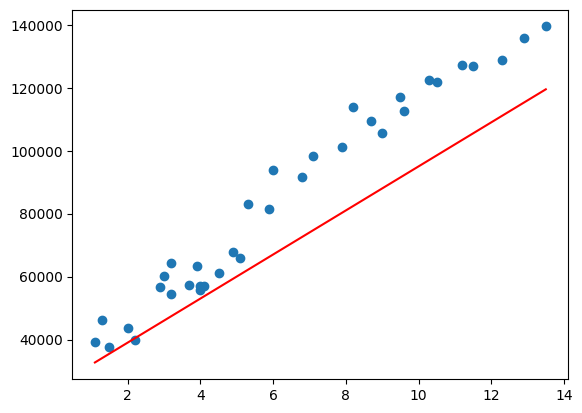

In [ ]:
plt.scatter(X1,y1)
plt.plot(X1,y_pred_1,c='r')


In [ ]:
# b = -150
# m = 8700
# lr = 0.001
# all_b = []
# all_cost = []

# epochs = 30

# for i in range(epochs):
#     slope = 0 # slope of error vs b / intecept
#     cost = 0 # error
#     for j in range(X1.shape[0]):
#         slope = slope - 2*(y[j] - (m * X[j]) -  b)
#         cost = cost + (y[j] - m * X[j] -b) ** 2

#     b = b - (lr * slope)
#     all_b.append(b)
#     all_cost.append(cost)
#     y_pred = m * X1 + b
#     plt.plot(X1,y_pred)
# plt.scatter(X1,y1)

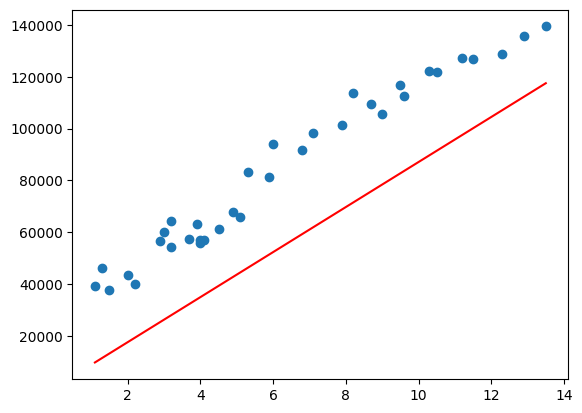

In [ ]:
b = 100
m = 8700
lr = 0.1 # 0.01

epochs = 100 # hyper paramters

for i in range(epochs):

  b = b - (lr * loss_slope_b)

  y_pred_3 = m * X1 + b
 # print(b)

plt.plot(X1,y_pred_3,c='r')

plt.scatter(X1,y1)


In [ ]:
from sklearn.datasets import make_regression
X2,y2 = make_regression(n_samples=100,n_features=1,n_targets = 1,n_informative = 1,noise=20,random_state=25)

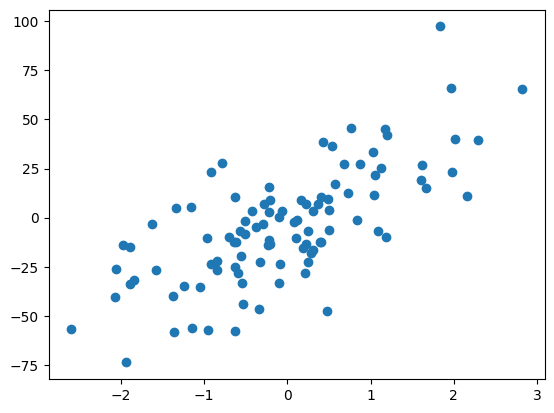

In [ ]:
plt.scatter(X2,y2)

In [ ]:
class GDRegressor:

  def __init__(self, learning_rate, epochs):
    self.m = 100
    self.b = -125
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self, X,y):
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
      loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X)

      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)

      print(self.b)
      print(self.m)
  def predict(self, X):
    return self.m*X + self.b

In [ ]:
gd = GDRegressor(0.01,100)

In [ ]:
gd.fit(X2,y2)

127.36369707860752
-1199.6975023888247
-258.87136242417495
789.4504930710909
332.2497969026809
-2254.8807767588705
-572.4433851553006
2404.3768056924737
812.1623606350129
-4726.476999466146
-1306.935151423702
6187.080598650658
1936.2799509737522
-10515.791554084988
-3027.3633644299834
15047.452662335569
4569.343663833247
-24076.324906741378
-7057.188301945181
35801.441714577435
10736.86970876262
-55839.68187648765
-16496.401693268515
84414.3056535486
25183.302329860384
-130240.21021484362
-38606.232970921075
198282.07991131936
59021.735107537854
-304511.41908923467
-90394.93811616304
464998.93145695305
138282.79303661894
-712713.5504561518
-211701.60694324275
1089740.034566386
323939.0066477135
-1668861.0468139367
-495842.866328925
2553095.063139123
758808.6709316404
-3908481.9712071754
-1161397.8277001712
5980767.628608236
1777420.5516552166
-9154431.894296335
-2720352.7206417113
14009536.441825585
4163354.1974516544
-21442221.446456753
-6371952.512218844
32815629.329892784
9752018.01

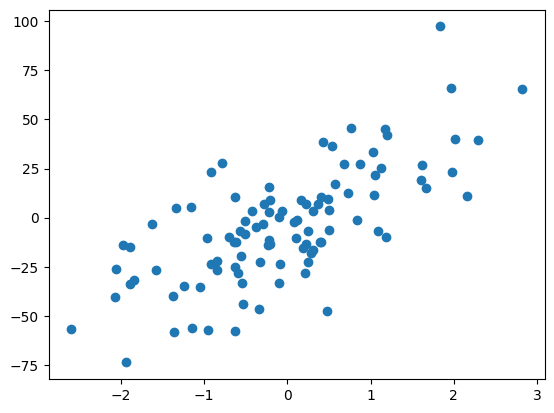

In [ ]:

plt.scatter(X2,y2)
#plt.plot(X2,gd.predict(X2),color='red')

MULTIPLE LINEAR REGRESSION


In [ ]:
X3,y3 = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=20,random_state=16)  #  2 features , 1 label

In [ ]:
data = {'f1':X3[:,0],'f2':X3[:,1],'target':y3}
df_new = pd.DataFrame(data)

In [ ]:
df_new

,f1,f2,target
0,0.648402,0.556420,90.967476
1,-0.803485,-0.333161,-65.535636
2,-0.837283,0.342241,-58.929976
3,-0.786897,0.118744,-55.977567
4,-2.253874,-1.005767,-263.957592
...,...,...,...
95,-0.638516,-0.842070,-95.389188
96,-0.405820,-1.238559,-124.390995
97,-0.427072,1.052092,29.293788
98,0.164903,0.253946,29.070901


In [ ]:
import plotly.express as px
px.scatter_3d(df_new,x = df_new['f1'],y = df_new['f2'],z = df_new['target'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train_1,X_test_1,y_train_1,y_test_1 = train_test_split(X3,y3,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [ ]:
reg.fit(X_train_1,y_train_1)

LinearRegression()

In [ ]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(x,y)

final = np.vstack([xGrid.ravel(),yGrid.ravel()]).T

z_final = reg.predict(final).reshape(10,10)

#z = z_final

In [ ]:
import plotly.graph_objects as go

In [ ]:
fig = px.scatter_3d(df_new,x = df_new['f1'],y = df_new['f2'],z = df_new['target'])

fig.add_trace(go.Surface(x = xGrid, y = yGrid, z =z_final ))

fig.show()

POLYNOMIAL LINEAR REGRESSION

In [ ]:
X4 = 6*np.random.rand(100,1)-3
y4 = 0.8*X4**2+0.9*X4+np.random.randn(100,1)

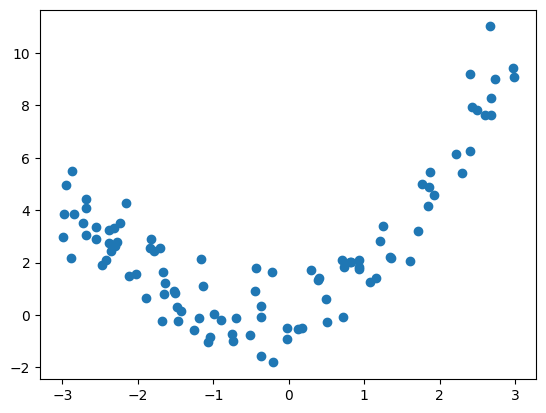

In [ ]:
plt.scatter(X4,y4)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X4,y4,test_size=0.2,random_state=2)

In [ ]:
reg.fit(X_train,y_train)


LinearRegression()

In [ ]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.12882939521245174

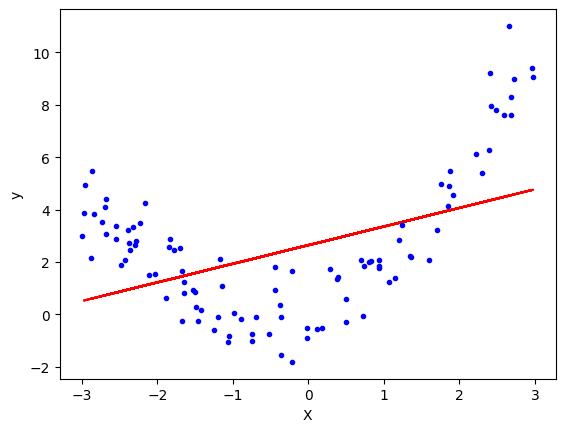

In [ ]:
plt.plot(X_train,reg.predict(X_train),color='r')
plt.plot(X4, y4, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:

from sklearn.preprocessing import PolynomialFeatures, StandardScaler #

In [ ]:
poly = PolynomialFeatures(degree=20,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)


LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_trans)


In [ ]:
r2_score(y_test,y_pred)


0.725905646670832

In [ ]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

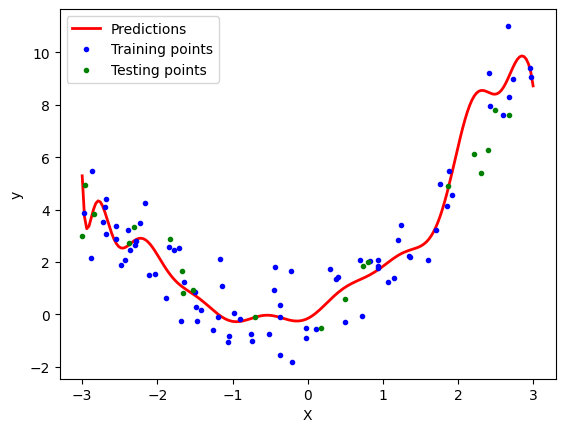

In [ ]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


In [ ]:
#change degree of polynomial features acc. to need

3d POLYNOMIAL REGRESSION

In [ ]:
x1 = 7 * np.random.rand(200, 1) - 2.8
x2 = 7 * np.random.rand(200, 1) - 2.8

z = x1**2 + x2**2 + 0.2*x1 + 0.2*x2 + 0.1*x1*x2 +2 + np.random.randn(200, 1)

In [ ]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x1.ravel(), y=x2.ravel(), z=z.ravel())
fig.show()

In [ ]:
lr = LinearRegression()
lr.fit(np.array([x1,x2]).reshape(200,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x1.ravel(), y=x2.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [ ]:
X_multi = np.array([x1,x2]).reshape(200,2)
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)


In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)
z_final = lr.predict(X_multi_trans).reshape(20,10)

In [ ]:
fig = px.scatter_3d(x1.ravel(), y=x2.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

GRADIENT DESCENT

In [ ]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)
X.shape

(100, 1)

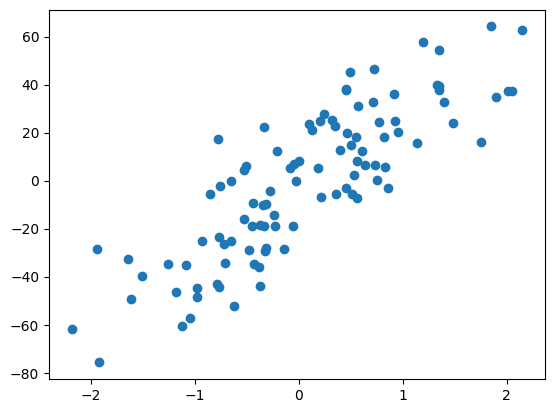

In [ ]:
plt.scatter(X,y)


In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


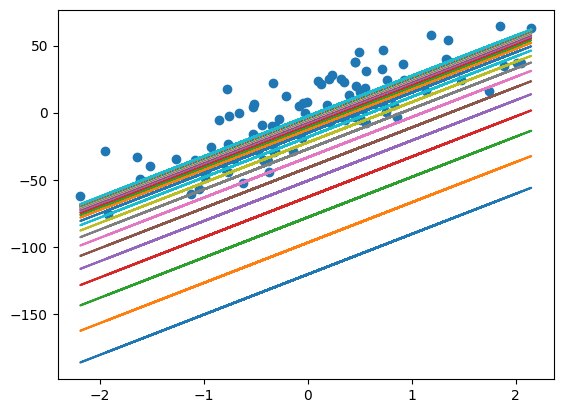

In [ ]:
#stochastic gradient descent

b = -150
m = 30
lr = 0.001
all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slope = 0 # slope of error vs b / intecept
    cost = 0 # error
    for j in range(X.shape[0]):
        slope = slope - 2*(y[j] - (m * X[j]) -  b)
        cost = cost + (y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope)
    all_b.append(b)
    all_cost.append(cost)
    y_pred = m * X + b
    plt.plot(X,y_pred)
plt.scatter(X,y)

In [ ]:
import random

In [ ]:
#mini batch gradient descent
learning_rate = 0.01
epochs = 30
batch_size=5

intercept_ = 0 # assume its zero

coef_ = np.ones(X_train.shape[1]) # assume 1  [1, 1, 1, ,1 .... 1]
for i in range(epochs):

    for j in range(int(X.shape[0]/batch_size)):
        i_random = random.sample(range(X_train.shape[0]), X_train.shape[1]) # but 10 [10x2]
        #print(X_train[i_random])
        y_hat = intercept_ + np.dot(X_train[i_random],coef_)
        loss_slope_intercept = -2* np.mean(y_train[i_random] - y_hat)

        intercept_ = intercept_ - learning_rate * loss_slope_intercept

        loss_slope_coef_b = -2* np.dot((y_train[i_random] - y_hat), X_train[i_random]) # /X_train[i_random].shape[0]
        coef_ = coef_ - learning_rate* loss_slope_coef_b

    print(intercept_)
    print(coef_)





1.0291878001528647
[[0.22974932]]
1.3873879878323419
[[-0.27865972]]
1.560009462000526
[[0.29475547]]
1.873694942745027
[[0.21970821]]
2.4620447684808475
[[0.26423922]]
2.379606550820144
[[0.78512394]]
2.424397584097475
[[1.16012542]]
2.693587277517365
[[0.95458633]]
2.371215368996079
[[0.7951585]]
2.598412922665457
[[1.07391289]]
2.4093816243379442
[[1.17076642]]
2.6628111902895433
[[0.79284966]]
2.474247405563318
[[0.93400512]]
2.5191240000363613
[[0.65007145]]
2.8323189353293587
[[0.94115872]]
3.039774656460124
[[0.64992405]]
3.1326138826803986
[[1.52229478]]
3.0370355538299747
[[0.81724378]]
2.977630969950829
[[0.7775243]]
3.0082989115685193
[[0.91811632]]
3.0832870222970694
[[0.30947082]]
2.7044079155289107
[[1.02410754]]
3.1718480630153576
[[0.86202456]]
2.933915959742655
[[0.81934482]]
2.8858775503214034
[[0.62638505]]
2.7232879471008866
[[0.52888934]]
2.787823829770746
[[0.34146474]]
2.652062834805992
[[0.49730938]]
2.479231424206462
[[0.43313171]]
2.5263392482074067
[[0.576334

In [ ]:
#Batch gradient descent

learning_rate = 0.01
epochs = 30

intercept_ = 0 # assume its zero
coef_ = np.ones(X.shape[1]) # assume 1  [1, 1, 1, ,1 .... 1]

for i in range(epochs):
  y_hat = intercept_ + np.dot(X,coef_)   # y_hat = b0+b1x1+b2x2

  loss_slope_b = -2* np.mean(y_train - y_hat) #  derivatives
  intercept_ = intercept_ - (learning_rate*loss_slope_b)

  loss_slope_m = -2* np.dot((y_tr - y_hat), X)/X.shape[0] #  derivatives  / weight
  coef_ = coef_- (learning_rate*loss_slope_m)

print(intercept_)
print(coef_)



ValueError: shapes (80,100) and (80,1) not aligned: 100 (dim 1) != 80 (dim 0)